In [6]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import *
from matplotlib import pyplot as plt
import datetime
import h5py
import os
import pygeodesy

def drone_angles_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                       start_file=0, stop_file=-1,
                                       use_ctime=False, output='degrees'):
    """
    Compute drone angles relative to a single dish location for a specific correlator file time range.
    Interpolates the drone positions to the correlator timestamps.

    Time handling matches the concat script: all times converted to float seconds since epoch.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)
    t_corr = np.concatenate(t_list)

    # Convert correlator times to seconds since epoch
    t_corr_sec = t_corr if use_ctime else t_corr  # already in seconds
    # fallback: ensure numeric type
    t_corr_sec = np.array(t_corr_sec, dtype=float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                                for x in df['time(millisecond)']])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(df['GPS:dateTimeStamp'], utc=True).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range.")
    df_masked = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df_masked.columns:
        lat = df_masked['RTKdata:Lat_P'].values
        lon = df_masked['RTKdata:Lon_P'].values
        alt = df_masked['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df_masked.columns:
        lat = df_masked['GPS(0):Lat'].values
        lon = df_masked['GPS(0):Long'].values
        alt = df_masked['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df_masked.columns:
        lat = df_masked['GPS:Lat'].values
        lon = df_masked['GPS:Long'].values
        alt = df_masked['GPS:heightMSL'].values
    elif 'latitude' in df_masked.columns:
        lat = df_masked['latitude'].values
        lon = df_masked['longitude'].values
        if 'altitude(meters)' in df_masked.columns:
            alt = df_masked['altitude(meters)'].values
        elif 'altitude(feet)' in df_masked.columns:
            alt = df_masked['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid_mask = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid_mask], lon[valid_mask], alt[valid_mask]
    drone_times = drone_times[valid_mask]

    # -----------------------
    # Step 5: Convert drone positions to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt)

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Compute angles relative to dish
    # -----------------------
    drone_xyz_rel = drone_xyz  # dish at origin
    #horizontal_dist = np.linalg.norm(drone_xyz_rel[:, :2], axis=1)
    horizontal_dist = np.abs(drone_xyz_rel[:, 1])
    vertical_dist = np.abs(drone_xyz_rel[:, 2])
    drone_angles = np.arctan2(horizontal_dist, vertical_dist)

    # -----------------------
    # Step 7: Interpolate angles to correlator timestamps
    # -----------------------
    angles_interp = np.interp(t_corr_sec, drone_times, drone_angles)

    if output.lower() == 'degrees':
        angles_interp = np.degrees(angles_interp)

    return angles_interp


array([13.30278734, 13.20669768, 13.1278026 , 13.03128785, 12.93484687,
       12.82867922, 12.74844408, 12.65210806, 12.55418377, 12.4563919 ,
       12.35873762, 12.26101391, 12.15215985, 12.05015577, 11.94537668,
       11.84149865, 11.72149401, 11.62516069, 11.51273998, 11.40301861,
       11.29357107, 11.18181357, 11.06552936, 10.94908785, 10.83709592,
       10.72420598, 10.61220085, 10.50064702, 10.38509784, 10.27468897,
       10.16045576, 10.03403168,  9.92334129,  9.81580272,  9.69194174,
        9.59630627,  9.4655481 ,  9.33469393,  9.19136096,  9.08241777,
        8.95398033,  8.81678427,  8.68061832,  8.5537624 ,  8.41674972,
        8.2994936 ,  8.16807202,  8.03307087,  7.9116449 ,  7.78649451,
        7.65262101,  7.51559968,  7.39612318,  7.26846365,  7.14814795,
        7.01778085,  6.8886293 ,  6.76547148,  6.64688179,  6.52640488,
        6.39864455,  6.270594  ,  6.13515525,  6.01869217,  5.89841732,
        5.76859179,  5.62251763,  5.50378504,  5.39192935,  5.24

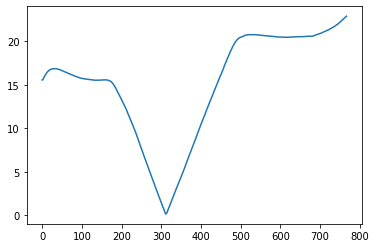

In [16]:
drone_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_processed/YaleApr2025_drone_files/Apr-12th-2025-03-58PM-Flight-Airdata.csv"
corr_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z"
dish_loc = [41.31899934, -72.92132019, 25] 

# Compute angles using the simplified function
drone_angles = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=101,
    stop_file=104,
    use_ctime=True,
    output='degrees'
)

# Preview first few angles
plt.plot(drone_angles)
len(drone_angles)
drone_angles[200:450]

## Apply manual time shift to drone timestamps (seconds) 

In [20]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import *
from matplotlib import pyplot as plt
import datetime
import h5py
import os
import pygeodesy

def drone_angles_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                       start_file=0, stop_file=-1,
                                       use_ctime=False, output='degrees',
                                       manual_drone_time_offset_s=0.0):
    """
    Compute drone angles relative to a single dish location for a specific correlator file time range.
    Interpolates the drone positions to the correlator timestamps.

    Time handling matches the concat script: all times converted to float seconds since epoch.

    NEW:
      manual_drone_time_offset_s: float (seconds)
          Added to drone timestamps (drone_times += offset) to manually shift alignment.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)
    t_corr = np.concatenate(t_list)

    # Convert correlator times to seconds since epoch
    t_corr_sec = t_corr if use_ctime else t_corr  # already in seconds
    t_corr_sec = np.array(t_corr_sec, dtype=float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                                for x in df['time(millisecond)']])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(df['GPS:dateTimeStamp'], utc=True).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # NEW: Apply manual time shift to drone timestamps (seconds)
    # -----------------------
    manual_drone_time_offset_s = float(manual_drone_time_offset_s)
    drone_times = drone_times + manual_drone_time_offset_s

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range (after applying manual offset).")
    df_masked = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df_masked.columns:
        lat = df_masked['RTKdata:Lat_P'].values
        lon = df_masked['RTKdata:Lon_P'].values
        alt = df_masked['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df_masked.columns:
        lat = df_masked['GPS(0):Lat'].values
        lon = df_masked['GPS(0):Long'].values
        alt = df_masked['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df_masked.columns:
        lat = df_masked['GPS:Lat'].values
        lon = df_masked['GPS:Long'].values
        alt = df_masked['GPS:heightMSL'].values
    elif 'latitude' in df_masked.columns:
        lat = df_masked['latitude'].values
        lon = df_masked['longitude'].values
        if 'altitude(meters)' in df_masked.columns:
            alt = df_masked['altitude(meters)'].values
        elif 'altitude(feet)' in df_masked.columns:
            alt = df_masked['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid_mask = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid_mask], lon[valid_mask], alt[valid_mask]
    drone_times = drone_times[valid_mask]

    # -----------------------
    # Step 5: Convert drone positions to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt)

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Compute angles relative to dish
    # -----------------------
    drone_xyz_rel = drone_xyz  # dish at origin

    # defining horizontal distance ignoring x
    horizontal_dist = np.abs(drone_xyz_rel[:, 1])
    vertical_dist = np.abs(drone_xyz_rel[:, 2])
    drone_angles = np.arctan2(horizontal_dist, vertical_dist)

    # -----------------------
    # Step 7: Interpolate angles to correlator timestamps
    # -----------------------
    angles_interp = np.interp(t_corr_sec, drone_times, drone_angles)

    if output.lower() == 'degrees':
        angles_interp = np.degrees(angles_interp)

    # -----------------------
    # Step 8: Print the max x-deviation (to get an idea of potential error)
    # -----------------------
    horizontal_x_dist = np.abs(drone_xyz_rel[:, 0])
    drone_angles_errors = np.arctan2(horizontal_x_dist, vertical_dist)

    horizontal_x_interp = np.interp(t_corr_sec, drone_times, horizontal_x_dist)
    angles_interp_errors = np.interp(t_corr_sec, drone_times, drone_angles_errors)

    if output.lower() == 'degrees':
        angles_interp_errors = np.degrees(angles_interp_errors)

    max_dev_deg = np.max(angles_interp_errors)
    avg_dev_deg = np.mean(angles_interp_errors)
    st_dev_deg  = np.std(angles_interp_errors)

    max_dev_m = np.max(horizontal_x_interp)
    avg_dev_m = np.mean(horizontal_x_interp)
    st_dev_m  = np.std(horizontal_x_interp)

    print(
        "Horizontal Deviation from Straight Path (x-direction):\n"
        "  Metric              |   Degrees   |   Meters\n"
        "  --------------------+-------------+-----------\n"
        f"  Max deviation       | {max_dev_deg:9.4f} | {max_dev_m:9.4f}\n"
        f"  Mean deviation      | {avg_dev_deg:9.4f} | {avg_dev_m:9.4f}\n"
        f"  Std. deviation      | {st_dev_deg:9.4f} | {st_dev_m:9.4f}"
    )

    return angles_interp

Horizontal Deviation from Straight Path (x-direction):
  Metric              |   Degrees   |   Meters
  --------------------+-------------+-----------
  Max deviation       |    0.8774 |    0.7522
  Mean deviation      |    0.5774 |    0.5002
  Std. deviation      |    0.1546 |    0.1310
768


array([16.18342242, 16.18342242, 16.26312249, 16.34661534, 16.44954328,
       16.52278043, 16.61738544, 16.6897758 , 16.77229725, 16.85447621,
       16.9121186 , 16.97708803, 17.03671351, 17.09810683, 17.14746152,
       17.19475272, 17.2366467 , 17.27427309, 17.31153479, 17.33871574,
       17.36587721, 17.38831444, 17.40782753, 17.4255683 , 17.43781414,
       17.45130718, 17.46068918, 17.47101454, 17.47839886, 17.48268467,
       17.48646357, 17.48566674, 17.48486975, 17.48215828, 17.47866798,
       17.47396883, 17.46686268, 17.45973531, 17.44968801, 17.43996268,
       17.42938181, 17.41847264, 17.40677095, 17.39164624, 17.37649845,
       17.35668768, 17.34089072, 17.32243389, 17.30346394, 17.28442307,
       17.26421808, 17.24386395, 17.2233503 , 17.20174608, 17.18116611,
       17.15868417, 17.13407565, 17.11586716, 17.09595196, 17.07521734,
       17.05372454, 17.03236058, 17.01240138, 16.98980003, 16.9727471 ,
       16.95313885, 16.93451166, 16.9175863 , 16.8982402 , 16.88

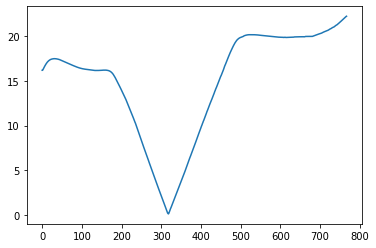

In [24]:
drone_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_processed/YaleApr2025_drone_files/Apr-12th-2025-03-58PM-Flight-Airdata.csv"
corr_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z"
dish_loc = [41.31900474, -72.92132617, 25]

# Compute angles using the simplified function
drone_angles = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=101,
    stop_file=104,
    use_ctime=True,
    output='degrees',
    manual_drone_time_offset_s=0.0
)

# Preview first few angles
plt.plot(drone_angles)
print(len(drone_angles))
drone_angles